<a href="https://colab.research.google.com/github/fabricejumel/5IRC-2026-2027-CYBER-SIA/blob/main/Attaques_yolov8_EOM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛡️ Laboratoire d'Attaques Adversariales sur YOLOv8, Expectation Over Transformation

In [1]:
!pip install ultralytics torch torchvision pillow matplotlib opencv-python

In [2]:
import torch
import torchvision.transforms as transforms
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from ultralytics import YOLO
import numpy as np

# Choix du device (CUDA 13 / GPU ou CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation du device : {device}")

Utilisation du device : cuda


In [3]:
def print_detections(yolo_results, model_names, title="Résultats de détection"):
    """
    Affiche proprement de manière textuelle toutes les bounding boxes,
    les classes et les scores de confiance détectés par YOLO.
    """
    print(f"\n--- {title} ---")

    boxes = yolo_results[0].boxes
    if len(boxes) == 0:
        print("🎯 Aucune détection (le modèle est complètement aveuglé !)")
        return

    for box in boxes:
        cls_id = int(box.cls[0].item())
        cls_name = model_names[cls_id]
        conf = box.conf[0].item()

        # Récupération des coordonnées [x_min, y_min, x_max, y_max]
        x1, y1, x2, y2 = [int(coord) for coord in box.xyxy[0].tolist()]

        print(f"Objet : {cls_name} | Confiance : {conf:.2f} | Box : [{x1}, {y1}, {x2}, {y2}]")

In [4]:
def apply_patch(image_path, patch_tensor, patch_coords):
    """
    Colle un patch de pixels (patch_tensor) sur l'image
    aux coordonnées exactes (x_min, y_min, x_max, y_max).
    """
    pil_img = Image.open(image_path).convert("RGB")
    to_tensor = transforms.ToTensor()
    to_pil = transforms.ToPILImage()

    img_tensor = to_tensor(pil_img).to(device)
    x_min, y_min, x_max, y_max = patch_coords

    img_tensor[:, y_min:y_max, x_min:x_max] = patch_tensor
    return to_pil(img_tensor.cpu())

In [5]:
def run_baseline(model, image_path):
    """Exécute l'inférence YOLO d'origine, affiche l'image et retourne les résultats."""
    results = model(image_path)
    results[0].show()
    print_detections(results, model.names, title="Détections YOLO avant application de patchs")
    return results

In [6]:
# Chargement du modèle nano pré-entraîné
model = YOLO("yolov8n.pt")
model.model.to(device)

from ultralytics.utils.downloads import safe_download
import os

# 1. Télécharger l'image d'origine si elle n'existe pas
raw_image_path = "bus.jpg"
if not os.path.exists(raw_image_path):
    safe_download("https://ultralytics.com/images/bus.jpg", dir=".")

# 2. ⚡ NORMALISATION DIRECTE EN 640x640
# Cela garantit un format parfait pour les couches de YOLO et fixe vos coordonnées x,y
pil_img = Image.open(raw_image_path).convert("RGB").resize((640, 640))
image_path = "bus_640.jpg"
pil_img.save(image_path)

print(f"Image prête, normalisée et enregistrée sous : {image_path}")





Image prête, normalisée et enregistrée sous : bus_640.jpg



image 1/1 /content/bus_640.jpg: 640x640 4 persons, 1 bus, 9.5ms
Speed: 42.4ms preprocess, 9.5ms inference, 24.2ms postprocess per image at shape (1, 3, 640, 640)


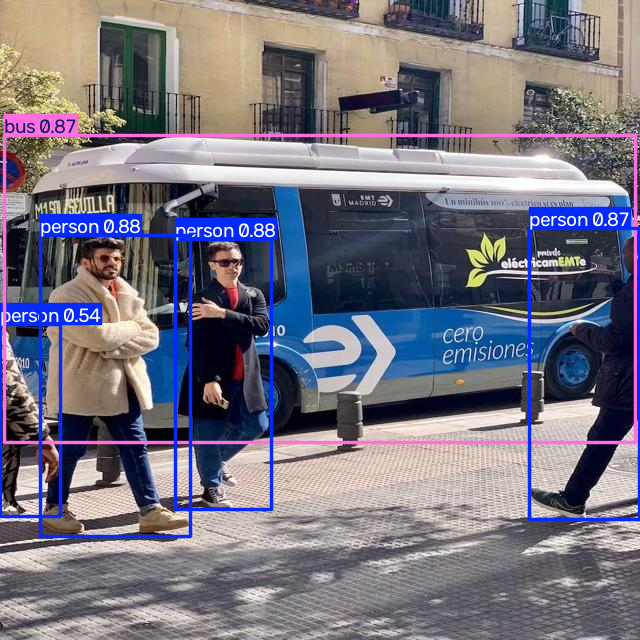


--- Détections YOLO avant application de patchs ---
Objet : person | Confiance : 0.88 | Box : [40, 235, 190, 536]
Objet : person | Confiance : 0.88 | Box : [175, 239, 271, 509]
Objet : person | Confiance : 0.87 | Box : [529, 228, 639, 519]
Objet : bus | Confiance : 0.87 | Box : [4, 135, 635, 442]
Objet : person | Confiance : 0.54 | Box : [0, 324, 60, 516]


In [7]:
run_baseline(model, image_path);


In [8]:
# Historique global pour stocker nos patchs et leurs résultats sans rien écraser
patch_experiments = []

In [9]:
import time
import torch
import torch.optim as optim
from PIL import Image
from torchvision import transforms
import pandas as pd

def create_and_optimize_patch(
    model, image_path, patch_coords=None, patch_type="random",
    num_iterations=500, lr=0.05, lambda_tv=0.05
):
    """
    Crée, optimise (si demandé) et retourne un patch avec son manifeste associé.
    Si patch_coords est None, le patch est considéré comme non localisé.
    """
    device = next(model.model.parameters()).device
    pil_img = Image.open(image_path).convert("RGB")
    orig_tensor = transforms.ToTensor()(pil_img).unsqueeze(0).to(device)

    # Gestion de la localisation
    if patch_coords is not None:
        x_min, y_min, x_max, y_max = patch_coords
        h, w = y_max - y_min, x_max - x_min
        location_status = f"Localisé : [{x_min}, {y_min}, {x_max}, {y_max}]"
    else:
        # Par défaut si non localisé, on prend une taille standard en haut à gauche
        h, w = 100, 100
        x_min, y_min, x_max, y_max = 0, 0, w, h
        location_status = "Non localisé"

    # --- 1. Création du patch selon le type ---
    if patch_type == "random":
        patch_tensor = torch.rand(3, h, w, device=device)
        desc = "Bruit aléatoire pur (0 à 1)"

    elif patch_type == "stealth_pixels":
        if patch_coords is None:
            raise ValueError("Un patch furtif basé sur les pixels réels nécessite des coordonnées (patch_coords) !")
        original_pixels = orig_tensor[:, :, y_min:y_max, x_min:x_max].clone().detach()
        patch_tensor = original_pixels.clone().detach().requires_grad_(True)
        desc = "Pixels réels d'origine (Initialisation furtive)"

    elif patch_type == "optimized_stealth_tv":
        if patch_coords is None:
            raise ValueError("Un patch optimisé nécessite des coordonnées (patch_coords) !")

        # Initialisation pixels réels + Optimisation
        original_pixels = orig_tensor[:, :, y_min:y_max, x_min:x_max].clone().detach()
        patch_tensor = original_pixels.clone().detach().requires_grad_(True)

        optimizer = optim.Adam([patch_tensor], lr=lr)
        model.model.train()

        print(f"🚀 Optimisation du patch ({patch_type}) sur {num_iterations} itérations...")
        for iteration in range(num_iterations):
            optimizer.zero_grad()
            noise = torch.randn_like(orig_tensor, device=device) * 0.02
            eot_img = torch.clamp(orig_tensor + noise, 0.0, 1.0)

            patched_img = eot_img.clone()
            patched_img[:, :, y_min:y_max, x_min:x_max] = patch_tensor

            preds = model.model(patched_img)
            tensor_preds = list(preds.values())[0] if isinstance(preds, dict) else (preds[0] if isinstance(preds, (list, tuple)) else preds)

            detection_loss = torch.mean(torch.sigmoid(tensor_preds))
            tv_loss = torch.sum(torch.abs(patch_tensor[:, :, :, :-1] - patch_tensor[:, :, :, 1:])) + \
                      torch.sum(torch.abs(patch_tensor[:, :, :-1, :] - patch_tensor[:, :, 1:, :]))

            total_loss = detection_loss + lambda_tv * tv_loss
            total_loss.backward()
            optimizer.step()

            with torch.no_grad():
                patch_tensor.clamp_(0.0, 1.0)

        desc = f"Optimisé avec EOT & TV Loss (lambda_tv={lambda_tv})"
    else:
        raise ValueError(f"Type de patch inconnu : {patch_type}")

    # --- 2. Création du Manifeste ---
    manifest = {
        "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
        "reference_image": image_path,
        "patch_type": patch_type,
        "description": desc,
        "coordinates": location_status if patch_coords else "Non localisé",
        "raw_coords": patch_coords if patch_coords else None,
        "shape": [3, h, w]
    }

    return patch_tensor.detach(), manifest

In [10]:
import time

# Vider l'historique
patch_experiments = []

# --- 0. BASELINE : Image d'origine (Sans patch) ---
results_orig = model(image_path)
manifest_orig = {
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "reference_image": image_path,
    "patch_type": "baseline",
    "description": "Image d'origine (Référence sans patch)",
    "coordinates": "N/A",
    "raw_coords": None,
    "shape": None,
}
patch_experiments.append({
    "manifest": manifest_orig,
    "patch_tensor": None,
    "results": results_orig
})

# Définition de la zone commune pour les patchs
patch_h, patch_w = 100, 100
x, y = 100, 350
patch_coords = (x, y, x + patch_w, y + patch_h)

# --- 1. Patch Aléatoire Pur ---
p_rand, m_rand = create_and_optimize_patch(model, image_path, patch_coords=patch_coords, patch_type="random")
img_rand = apply_patch(image_path, p_rand, patch_coords)
img_rand.save("patch_1_random.jpg")
patch_experiments.append({"manifest": m_rand, "patch_tensor": p_rand, "results": model("patch_1_random.jpg")})

# --- 2. Bruit optimisé agressivement (sans pixels d'origine) ---
p_opt_raw, m_opt_raw = create_and_optimize_patch(
    model, image_path, patch_coords=patch_coords, patch_type="optimized_stealth_tv",
    num_iterations=300, lambda_tv=0.0
)
m_opt_raw["description"] = "Bruit optimisé agressivement (sans pixels d'origine)"
img_opt_raw = apply_patch(image_path, p_opt_raw, patch_coords)
img_opt_raw.save("patch_2_opt_raw.jpg")
patch_experiments.append({"manifest": m_opt_raw, "patch_tensor": p_opt_raw, "results": model("patch_2_opt_raw.jpg")})

# --- 3. Furtif pixels réels optimisés (sans TV Loss) ---
p_stealth, m_stealth = create_and_optimize_patch(
    model, image_path, patch_coords=patch_coords, patch_type="optimized_stealth_tv",
    num_iterations=300, lambda_tv=0.0
)
m_stealth["description"] = "Furtif pixels réels optimisés (sans TV Loss)"
img_stealth = apply_patch(image_path, p_stealth, patch_coords)
img_stealth.save("patch_3_stealth.jpg")
patch_experiments.append({"manifest": m_stealth, "patch_tensor": p_stealth, "results": model("patch_3_stealth.jpg")})

# --- 4. Optimisé avec EOT & TV Loss (lambda_tv=0.05) ---
p_tv, m_tv = create_and_optimize_patch(
    model, image_path, patch_coords=patch_coords, patch_type="optimized_stealth_tv",
    num_iterations=300, lambda_tv=0.05
)
img_tv = apply_patch(image_path, p_tv, patch_coords)
img_tv.save("patch_4_stealth_tv.jpg")
patch_experiments.append({"manifest": m_tv, "patch_tensor": p_tv, "results": model("patch_4_stealth_tv.jpg")})

print(f"\n🎉 Étude d'ablation complète générée ! {len(patch_experiments)} configurations enregistrées (Baseline + 4 patchs).")


image 1/1 /content/bus_640.jpg: 640x640 4 persons, 1 bus, 11.6ms
Speed: 1.1ms preprocess, 11.6ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/patch_1_random.jpg: 640x640 5 persons, 1 bus, 8.3ms
Speed: 0.9ms preprocess, 8.3ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


NameError: name 'optim' is not defined

In [ ]:
for i, exp in enumerate(patch_experiments):
    print(f"\n==============================================")
    print(f"EXPERIENCE #{i+1} : {exp['manifest']['description']}")
    print(f"==============================================")
    print_detections(exp["results"], model.names, title=f"Résultats Patch #{i+1}")

In [ ]:
import pandas as pd

# Génération des données de synthèse à partir de l'historique
summary_data = []

for i, exp in enumerate(patch_experiments):
  manifest = exp["manifest"]
  boxes = exp["results"][0].boxes

  # Extraction des scores pour la classe 'person' (0) et 'bus' (5)
  person_confs = [b.conf[0].item() for b in boxes if int(b.cls[0].item()) == 0]
  bus_confs = [b.conf[0].item() for b in boxes if int(b.cls[0].item()) == 5]

  summary_data.append({
      "Exp #": i,
      "Type": manifest["patch_type"],
      "Description": manifest["description"],
      "Nb Personnes": len(person_confs),
      "Conf Max (Person)": f"{max(person_confs):.2f}" if person_confs else "N/A",
      "Conf Min (Person)": f"{min(person_confs):.2f}" if person_confs else "N/A",
      "Conf (Bus)": f"{bus_confs[0]:.2f}" if bus_confs else "Absent",
  })

# Création du DataFrame et affichage en format Markdown statique
df_summary = pd.DataFrame(summary_data)
print(df_summary.to_markdown(index=False))